In [1]:
import numpy as np
import astropy.units as u
from astropy.units import Quantity
import astropy.constants as const
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.time import Time
from scipy import integrate
import pandas as pd
from sparse import COO
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from cycler import cycler

from lmfit.lineshapes import gaussian

from pathlib import Path
import itertools
import warnings

from cosipy.response import FullDetectorResponse, DetectorResponse, PointSourceResponse
from cosipy import UnBinnedData, BinnedData
from FullDetectorResponseNew import FullDetectorResponse
from DetectorResponseNew import DetectorResponse
from cosipy.spacecraftfile import SpacecraftFile
from cosipy import test_data

from histpy import Histogram, Axes, Axis, HealpixAxis
import healpy as hp
import mhealpy as mhp
from mhealpy import HealpixMap, HealpixBase
from scoords import Attitude, SpacecraftFrame

from threeML import Model, Powerlaw, Gaussian, Constant, Band
from tqdm import tqdm

from astromodels import PointSource
from threeML import PluginPrototype, Model, JointLikelihood, DataList

import copy
# from cosipy import COSILike

plt.rcParams.update(plt.rcParamsDefault)

# Matplotlib style template
## For black, set #000000. For navy, set #002060
defaultcolor = '#002060'
plt.rcParams.update({'text.color': defaultcolor, 'axes.labelcolor': defaultcolor, 
                     'xtick.color': defaultcolor, 'ytick.color': defaultcolor,
                     'axes.prop_cycle': cycler(color=['orange', 'limegreen', 'b', 'r']),
                     'font.family':'serif', 'font.serif': 'Times New Roman',
                     'font.size': 22, 'lines.linewidth': 3,
                     'figure.figsize': (9.6, 5.4), 'figure.dpi': 100})

DATA_DIR = Path('/Users/penguin/Documents/Grad School/Research/COSI/COSIpy/docs/DC3/')
response_path = DATA_DIR / 'data/responses/Response44Ti.o4.e1154_1160.s9607532021290.m1215.filtered.nonsparse.binnedimaging.imagingresponse_nside16.area.h5'
# response_path = DATA_DIR / 'data/responses/SMEXv12.44Ti.HEALPix04.E_1143_1171keV.binnedimaging.imagingresponse.nonsparse_nside16.area.h5'

13:26:08 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=685611;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=407298;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#48\48]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=963853;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=332632;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#69\69]8;;\
                  will not be available.                                                                           

/Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=235100;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=783435;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

/Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=261527;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=361599;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#144\144]8;;\
                  software installed and configured?                                                               

13:26:10 WARNING   No fermitools installed                                              ]8;id=973275;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=76789;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=770617;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=388583;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=987957;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=410921;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=595251;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=113542;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

In [2]:
pix = 0

with FullDetectorResponse.open(response_path) as f:
    print(f.__dict__)
    nside = f.nside
    # print(f._axes['NuLambda'].edges)
    dr = f[pix]

{'_file': <HDF5 file "Response44Ti.o4.e1154_1160.s9607532021290.m1215.filtered.nonsparse.binnedimaging.imagingresponse_nside16.area.h5" (mode r)>, '_drm': <HDF5 group "/DRM" (2 members)>, '_unit': Unit("cm2"), '_sparse': False, '_axes': <histpy.axes.Axes object at 0x10471cf40>, '_pix_rangesets': None, '_pix_rangesets_argsort': None, '_uniq': None, '_scheme': 'RING', '_order': 4, '_coordsys': <SpacecraftFrame Frame (attitude=None, obstime=None, location=None)>, '_npix_ratio_max': 1125899906842624}


In [23]:
with FullDetectorResponse.open(response_path) as f:
    rsp = np.array(f._file['DRM']['CONTENTS'])

In [43]:
(rsp.sum(axis=(0,1,2,4)) / dr.get_effective_area().contents.value)

array([ 0.        ,  0.21316058,  5.45235598, 10.92071537, 14.71690744,
       22.38463862, 39.40368329, 39.49149487, 13.38560653, 14.25964125,
       14.94214326, 14.6127427 , 15.92073076, 16.90622081, 16.30080388,
       17.82941767, 18.20590796, 20.45891068, 24.79868328, 25.24085904,
       28.23351757, 27.40809464, 26.99158639, 26.52361127, 26.24255469,
       25.75289111, 25.36047118, 24.96329769, 24.64236099, 24.24832954,
       23.88438039, 23.48788442, 23.13977072, 22.93530223, 22.57110255,
       22.09581015, 21.58936925, 21.05218173, 20.48709514, 19.87570714,
       19.20597263, 18.49629426, 17.74737371, 16.94074743, 16.0736473 ,
       15.14476131, 14.15425429, 13.11951042, 12.03578399, 10.9218905 ,
        9.77542945,  8.58545395,  7.37468601,  6.15388446,  4.96029851,
        3.82786391,  2.79281112,  1.87499729,  1.07450282,  0.34916983])

Text(0.5, 1.0, 'Healpix Map [2000:]')

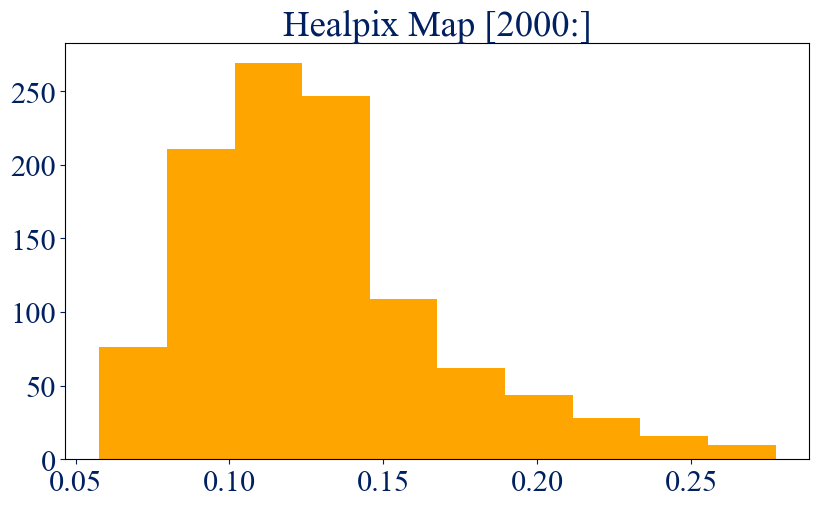

In [41]:
plt.hist((rsp.sum(axis=(2,3,4)) / dr.get_effective_area().contents)[2000:])
plt.title('Healpix Map [2000:]')

### Data

In [326]:
name = 'CasApartiallyresolved'
point_source = UnBinnedData(DATA_DIR / '44Ti/inputs.yaml')
data = point_source.get_dict_from_fits(DATA_DIR / f'44Ti/sources/{name}_3months_unbinned_data_filtered_with_SAAcut.fits')
# data = point_source.get_dict_from_fits(DATA_DIR.parent / 'DC2/44Ti/data/Ti44_CasA_3months_unbinned_data.fits')

# idx = data['Energies'] < 10**3.25
# data['Energies'] = data['Energies'][idx]
target_coord = SkyCoord.from_name('Cas A').galactic

l = target_coord.l.value
b = target_coord.b.value

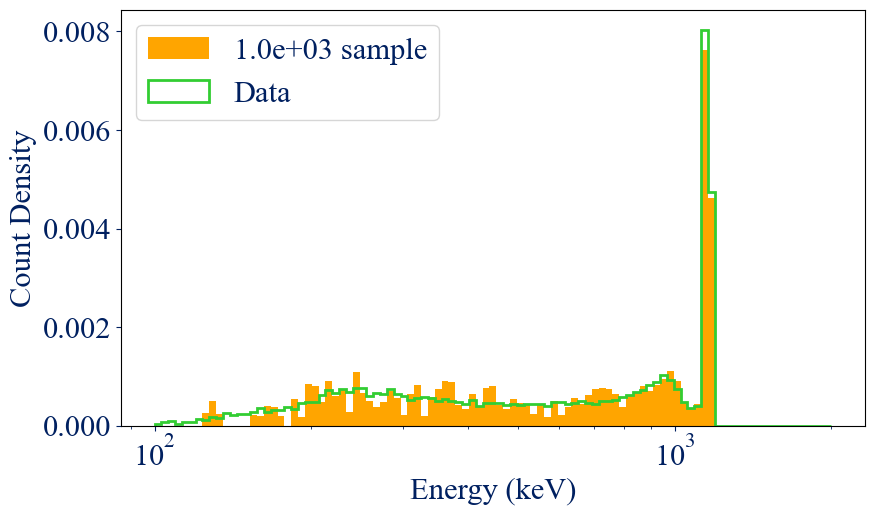

In [327]:
num_samples = 1000
bins = np.logspace(2, 3.3, 100)*u.keV
indices = np.random.choice(np.arange(len(data['Energies'])), num_samples, replace=False)
energy_samples = data['Energies'][indices] * u.keV
phi_samples = data['Phi'][indices] * u.rad
psi_gal_samples = data['Psi galactic'][indices] * u.deg
chi_gal_samples = data['Chi galactic'][indices] * u.deg

plt.hist(energy_samples, bins=bins, density=True, label=f'{num_samples:.1e} sample')
plt.hist(data['Energies'], bins=bins.value, density=True, lw=2, histtype='step', label='Data')
plt.xlabel('Energy (keV)')
plt.ylabel('Count Density')
plt.xscale('log')
plt.legend()
plt.show()

In [328]:
nside = 32

#### Plots

In [ ]:
Psi_sc = data['Psi local'] * u.rad
Chi_sc = data['Chi local'] * u.rad
# pixels = hp.ang2pix(nside=16, theta=Psi_sc.value, phi=Chi_sc.value, nest=False, lonlat=False)       # theta = polar angle (co-latitude), phi = azimuthal angle (longitude-like)

Psi_gal = data['Psi galactic'] * u.deg
Chi_gal = data['Chi galactic'] * u.deg
# Chi_gal = np.where(Chi_gal > 180 * u.deg, Chi_gal - 360 * u.deg, Chi_gal)

pixels = hp.ang2pix(nside=nside, theta=Chi_gal.value, phi=Psi_gal.value, nest=False, lonlat=True)      # theta = l, phi = b

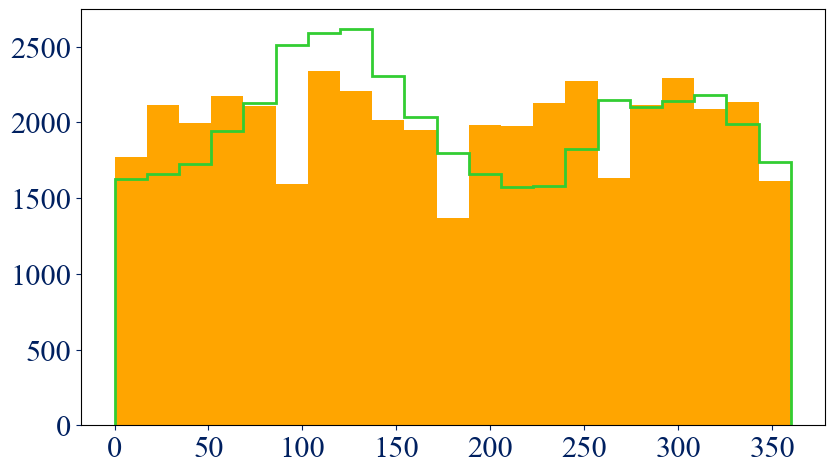

In [6]:
plt.hist(Chi_sc.to(u.deg), bins=21)
plt.hist(Chi_gal, bins=21, histtype = 'step', lw=2)     # l
plt.show()

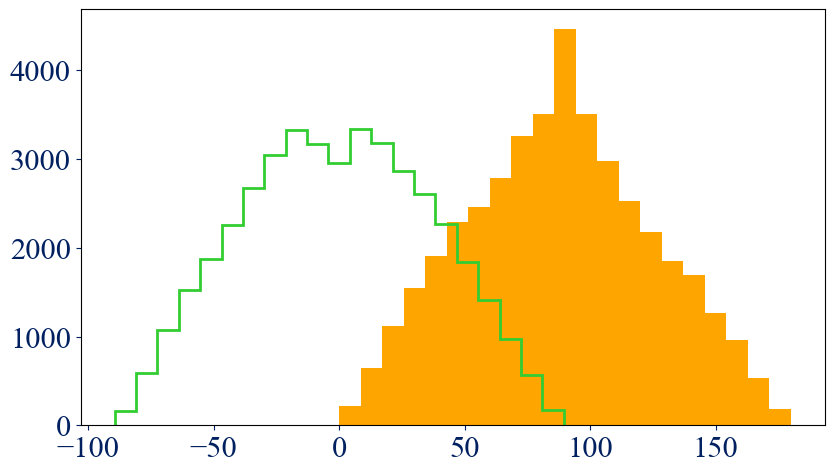

In [7]:
plt.hist(Psi_sc.to(u.deg), bins=21)
plt.hist(Psi_gal, bins=21, histtype = 'step', lw=2)     # b
plt.show()

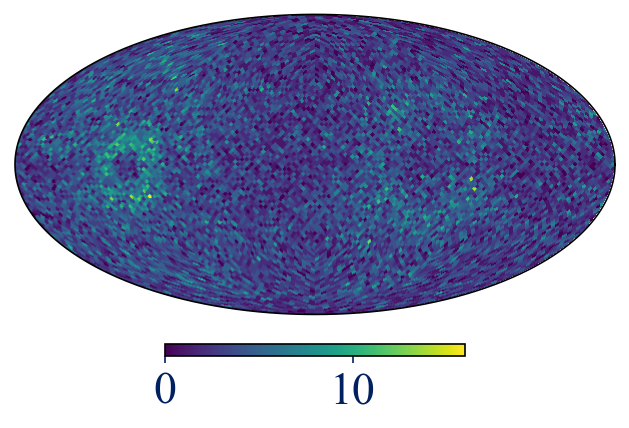

In [8]:
# Define the grid and initialize
m = HealpixMap(nside = nside, scheme = 'RING', dtype = int)

for p in pixels:
    m[p] += 1

m.plot()
plt.show()

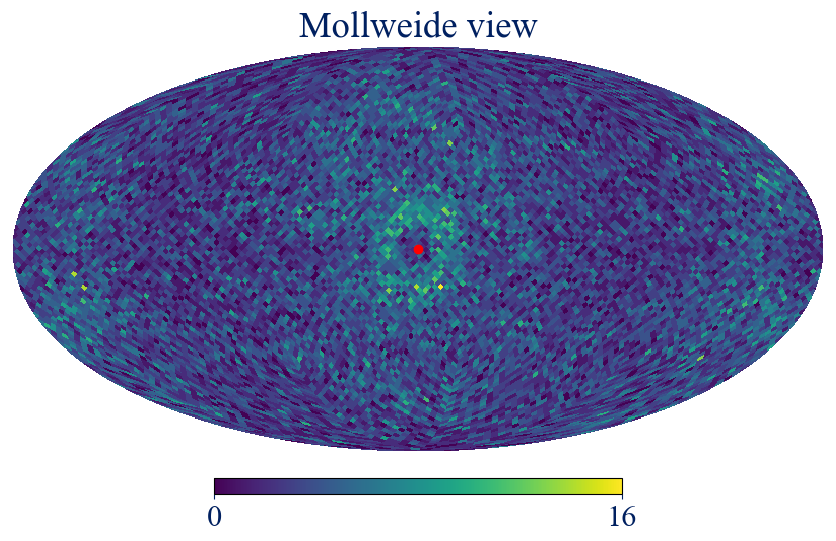

In [9]:
hp.mollview(m._data, rot=[l, b])
hp.projplot(l, b, c='r', marker='o', lonlat=True)
plt.show()

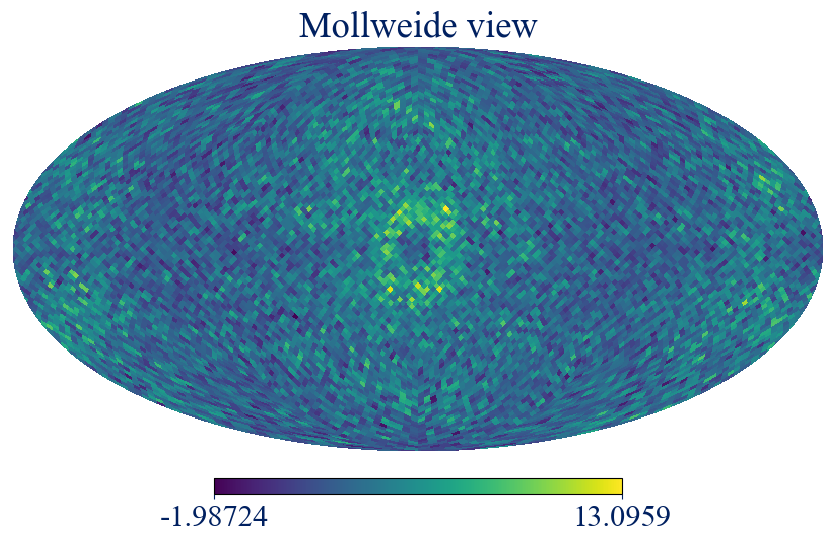

In [10]:
# Rotate the grid
rot_custom = hp.Rotator(rot=[l, b], inv=False)
data_rotated_alms = rot_custom.rotate_map_alms(m._data)

hp.mollview(data_rotated_alms)
plt.show()

#### 

In [329]:
rot_custom = hp.Rotator(rot=[l, b-90], inv=False)       # -90 ensures that Cas A is situated at hp pixel = 0

ang_rot = rot_custom(chi_gal_samples.value, psi_gal_samples.value, lonlat=True)
pixels_rot = hp.ang2pix(nside=nside, theta=ang_rot[0], phi=ang_rot[1], nest=False, lonlat=True)     # l, b
ang_rot

array([[  82.09399571,   21.18542839,  144.09382204, ...,  179.60510232,
        -135.06501634, -128.73203333],
       [ -15.87295653,   20.78444192,  -26.98508998, ...,   49.23171818,
         -52.16087633,   26.95251369]])

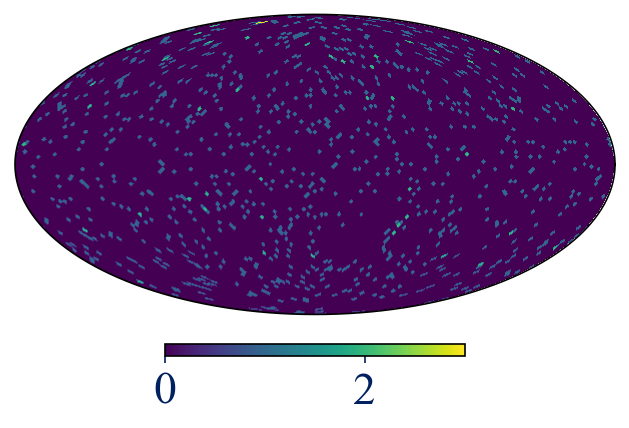

In [330]:
# Define the grid and initialize
m_rot = HealpixMap(nside = nside, scheme = 'RING', dtype = int)

for p in pixels_rot:
    m_rot[p] += 1

m_rot.plot()
plt.show()

In [331]:
Psi_sc_onaxis = ang_rot[1] * u.deg      # b
Chi_sc_onaxis = ang_rot[0] * u.deg      # l

### Interpolation

In [90]:
def get_all_interp_weights(dr, target: dict):
    indices = []
    weights = []

    for label in dr.axes.labels:

        if label == 'Ei':
            key = label

        elif label == 'Eps':
            key = 'Em'

        elif label == 'Phi':
            key = label

        elif label == 'Theta':
            # label = 'ThetaZeta'
            axis_type = 'Axis'      # Theta, Zeta have axis_type = 'Axis'. PsiChi axis_type = 'HealpixAxis'

            # NuLambda_sc = np.array([0])         # Placeholder. FullDetectorResponse object depends on NuLambda. Detector Response object does not. 
            # I/O with radians not degrees
            Theta, Zeta = transform_PsiChi_to_ThetaZeta(target['Phi'].to(u.rad).value, \
                                                 target['Psi_sc'].to(u.rad).value, target['Chi_sc'].to(u.rad).value)        # target['Ei', 'Em'] do not matter as we are throwing away the spectral component returned bu the function. 
            
            Theta = Theta * u.rad
            Zeta = Zeta * u.rad
            print(Theta, Zeta)

            # Theta axis
            idx, w = dr.axes['Theta'].interp_weights(Theta)
            indices.append(idx.reshape(-1))
            weights.append(w.reshape(-1))

            # Zeta axis
            idx, w = dr.axes['Zeta'].interp_weights(Zeta)
            indices.append(idx.reshape(-1))
            weights.append(w.reshape(-1))

            continue
    
        elif label == 'Zeta':
            continue

        elif label == 'PsiChi':
            key = label

        else:
            raise ValueError(f'Label: {label} is not supported')
        
        axis = dr.axes[label]

        axis_scale = axis._scale
        axis_type = str(type(axis)).split('.')[-1].strip("'>")      # XXX: Could probably be simplified using `isinstance()`

        # Scale
        if axis_scale in ['linear', 'log']:   # To ensure nonlinear binning parametrizations are converted to a linear scale.

            # Axis Type
            if axis_type in ['Axis', 'HealpixAxis']:

                if key == 'Ei':
                    idx, w = axis.interp_weights(target[key])

                elif key == 'Em':
                    centers = dr.transform_Eps_to_Em(axis.centers, target['Ei'])      # Transform coordinates to more physical units      # TODO: Generalize this
                    absdiff = np.abs(centers - target[key])                             # Calculate absolute difference to given target
                    idx = np.argpartition(absdiff, (1,2))[:2]                               # Find indices corresponding to two smallest absdiff
                    w = 1 - np.partition(absdiff, (1,2))[:2] / (centers[1] - centers[0])    # Calculate weights corresponding to two smallest absdiff

                elif key == 'Phi':
                    idx, w = axis.interp_weights(target[key])

                elif key == 'PsiChi':
                    idx, w = axis.interp_weights(SkyCoord(target['Chi_sc'], target['Psi_sc'], frame=SpacecraftFrame()))     # l, b

            else:
                raise ValueError(f'Axis type: {axis_type} is not supported')

        else:
            raise ValueError(f'{axis_scale} binning / scale scheme is not supported')
        
        indices.append(idx)
        weights.append(w)
    
    return (indices, weights)

def get_interp_response(dr, target: dict):
    """
    Currently only supports nonlinear spectral responses (
    and for a particular parametrization)
    TODO: In the future, this will also support nonlinear / 
    piecewise-linear directional responses.
    """

    # target = dict(sorted(target.items()))       # Sort dictionary by key (XXX: assuming response matrix also sorts in the same way)
    indices, weights = get_all_interp_weights(dr, target)
    perm_indices = list(itertools.product(*indices))
    perm_weights = list(itertools.product(*weights))

    if len(target) == len(dr.axes):
        pass
    else:
        warnings.warn('len(target) != len(dr.axes)')
    
    interpolated_response_value = 0
    for idx, w in zip(perm_indices, perm_weights):
        interpolated_response_value += np.prod(w) * dr.contents[idx]
    
    return interpolated_response_value

In [91]:
hist = dr.project('Phi', 'PsiChi')
dr2 = DetectorResponse(coord = dr.coord, edges=hist.axes, contents=hist.contents, unit=dr.unit)

#### Plots

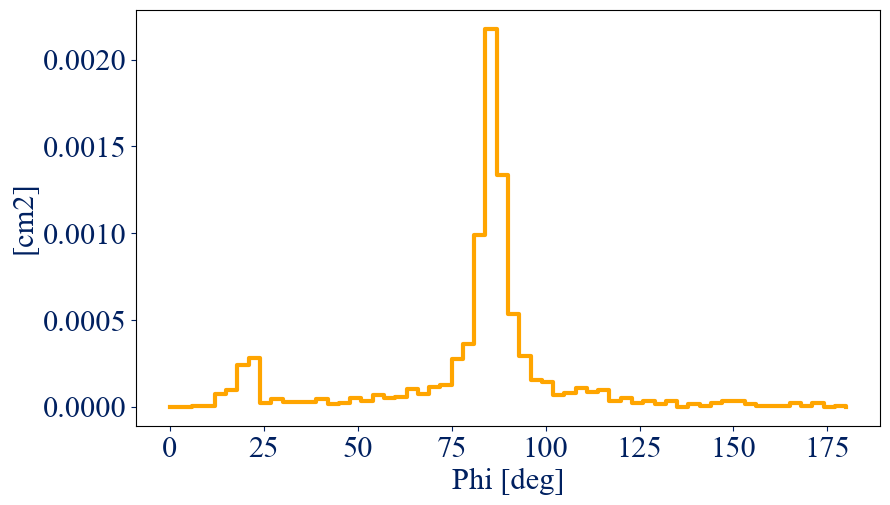

In [16]:
dr2.slice[:,1500].project('Phi').plot()
plt.show()

In [17]:
hp.pix2ang(nside=16, ipix=1500, lonlat=True)

(337.49999999999994, 2.388015463268772)

In [18]:
Phi0 = 45 * u.deg
Psi_gal0 = 2.388 * u.deg     # b
Chi_gal0 = 337.5 * u.deg       # l
target = {'Phi': Phi0, 'Psi_sc': Psi_gal0, 'Chi_sc': Chi_gal0}

get_interp_response(dr2, target)


WARNING UserWarning: len(target) != len(dr.axes)



<Quantity 1.81444463e-05 cm2>


WARNING UserWarning: len(target) != len(dr.axes)



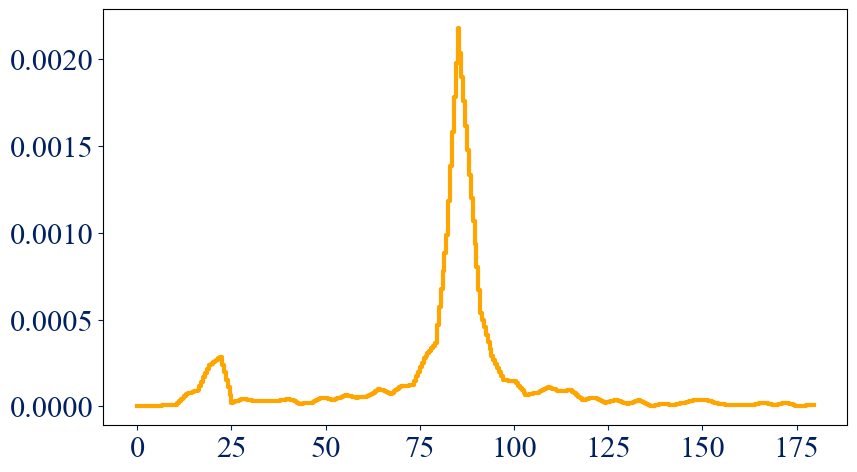

In [19]:
Phi = np.arange(180, step=0.5) * u.deg
rsp = []
for p in Phi:
    target = {'Phi': p, 'Psi_sc': Psi_gal0, 'Chi_sc': Chi_gal0}
    rsp.append(get_interp_response(dr2, target))
plt.step(Phi, Quantity(rsp))
plt.show()

### Spectrum

In [ ]:
from threeML.plugin_prototype import PluginPrototype
from threeML.utils.statistics.likelihood_functions import poisson_log_likelihood_ideal_bkg

class COSILikeNew(PluginPrototype):

    def __init__(self, name, dr2, exposure_time, energy_samples, phi_samples, psi_samples, chi_samples, 
                 spectrum_unit, nuisance_param, Eiedges = np.array([1154, 1160]) * u.keV):
        super().__init__(name, nuisance_param)  # Or 'extended' if needed
        self._dr2 = dr2
        self._exposure_time = exposure_time.to('s')
        self._energy_samples = energy_samples
        self._phi_samples = phi_samples
        self._psi_samples = psi_samples
        self._chi_samples = chi_samples

        self._Eiedges = Eiedges
        self._delta_Ei = Eiedges[-1] - Eiedges[0]
        self._delta_Em = Eiedges[-1] - Eiedges[0]
        self._spectrum_unit = spectrum_unit
        self._observed_events = energy_samples  # These are your Em samples
        self._n_observed = len(energy_samples)

    def set_model(self, likelihood_model):
        self._likelihood_model = likelihood_model

    def _compute_predicted_a(self):
        aj = []
        Eiedges = self._Eiedges / u.keV
        spectrum = self._likelihood_model.source.spectrum.main.shape
        integrated_spectrum = integrate.quad(spectrum, Eiedges[0], Eiedges[-1])[0] * self._spectrum_unit * u.keV
        for energy, phi, psi, chi in tqdm(zip(self._energy_samples, self._phi_samples, self._psi_samples, self._chi_samples)):
            target = {'Phi': phi, 'Psi_sc': psi, 'Chi_sc': chi}
            # print(energy, target, get_interp_response(self._dr2, target))
            aj.append(get_interp_response(self._dr2, target) * integrated_spectrum * self._exposure_time.to('s'))
        
        aj = Quantity(aj)
        return aj

    def _compute_predicted_c(self):
        # mod_rsp = lambda y, x: get_interp_response(dr2, {'Phi': x, 'PsiChi': y})
        delta_Em = self._delta_Em / u.keV      # Assuming R is normalized over units as listed for each axis. XXX: How exactly is the response file normalized? I can't multiple delta_Em and then not multiply the widths of each Phi and PsiChi bin. 
        Eiedges = self._Eiedges / u.keV
        spectrum = self._likelihood_model.source.spectrum.main.shape
        integrated_spectrum = (integrate.quad(spectrum, Eiedges[0], Eiedges[-1])[0] *       # As D and P normalize to 1, np.sum(R) is determined by Aeff.                                                                                                                                                     
                              self._spectrum_unit * u.keV)
        c = (np.sum(self._dr2.contents)) * integrated_spectrum * self._exposure_time.to('s')                  # Interpolated response won't improve anything as we are still going to numerically integrate (i.e., sum over rectangular blocks of area)
        
        return c

    def get_log_like(self):
        aj = self._compute_predicted_a()
        c = self._compute_predicted_c()
        log_like = -c + np.sum(np.log(aj + 1e-12))
        return -log_like

    def inner_fit(self):
        return -2.0 * self.get_log_like()  # 3ML minimizes -2 logL

    def get_number_of_data_points(self):
        return self._n_observed

    def get_number_of_model_parameters(self):
        return self._likelihood_model.get_number_of_free_parameters()

#### Plots

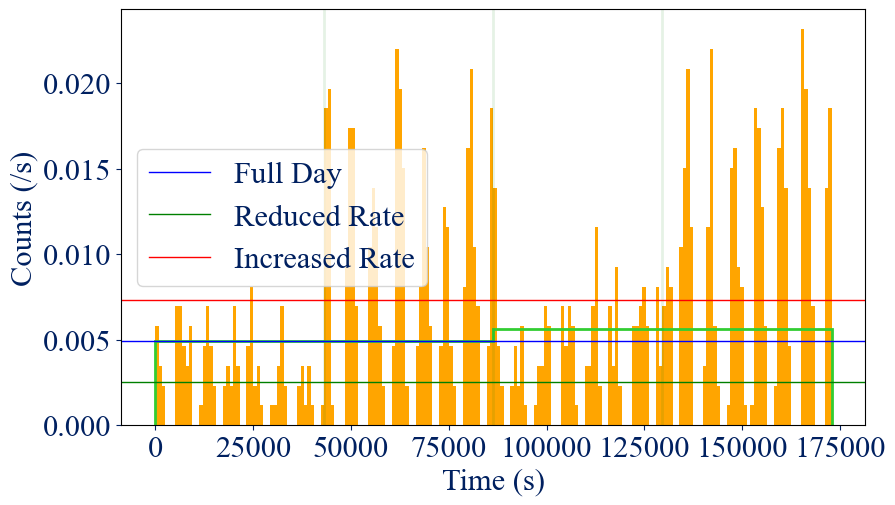

In [42]:
t0 = data['TimeTags'].min()
numdays = 2
bins = np.linspace(0, 86400*numdays, 100 * numdays + 1)
counts, _ = np.histogram(data['TimeTags'] - t0, bins=bins)
plt.stairs(counts / np.diff(bins), bins, fill=True)

counts, bins = np.histogram(data['TimeTags'] - t0, bins=np.arange(0, 86400*numdays+1, 86400))
plt.stairs(counts / np.diff(bins), bins, lw=2)

for i in range(1, numdays*2):
    plt.axvline(i * 86400/2, c='g', lw=2, alpha=0.1)

ff = 1#15/5

cond = (data['TimeTags'] < t0+86400)
plt.axhline(len(data['TimeTags'][cond]) / 86400 * ff, label='Full Day', lw=1, c='b')
cond = (data['TimeTags'] < t0+86400/2)
plt.axhline(len(data['TimeTags'][cond]) / (86400/2) * ff, label='Reduced Rate', lw=1, c='g')
cond = (data['TimeTags'] < t0 + 86400) & (data['TimeTags'] > t0 + 86400/2)
plt.axhline(len(data['TimeTags'][cond]) / (86400/2) * ff, label='Increased Rate', lw=1, c='r')

plt.xlabel('Time (s)')
plt.ylabel('Counts (/s)')
plt.legend()
plt.show()

74.0 34.0
139.0 176.0


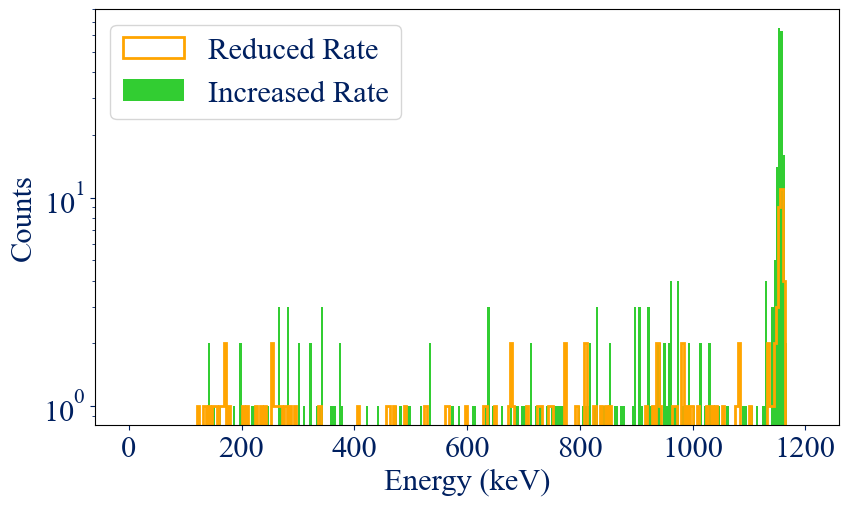

In [23]:
bins = np.linspace(0, 1200, 301)

cond = (data['TimeTags'] < t0 + 86400/2)
counts, _, _ = plt.hist(data['Energies'][cond], bins=bins, histtype='step', lw=2, label='Reduced Rate')
print(np.sum(counts[:275]), np.sum(counts[275:]))
cond = (data['TimeTags'] < t0 + 86400) & (data['TimeTags'] > t0 + 86400/2)
counts, _, _ = plt.hist(data['Energies'][cond], bins=bins, label='Increased Rate')
print(np.sum(counts[:275]), np.sum(counts[275:]))
plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.yscale('log')
plt.legend()
plt.show()

####

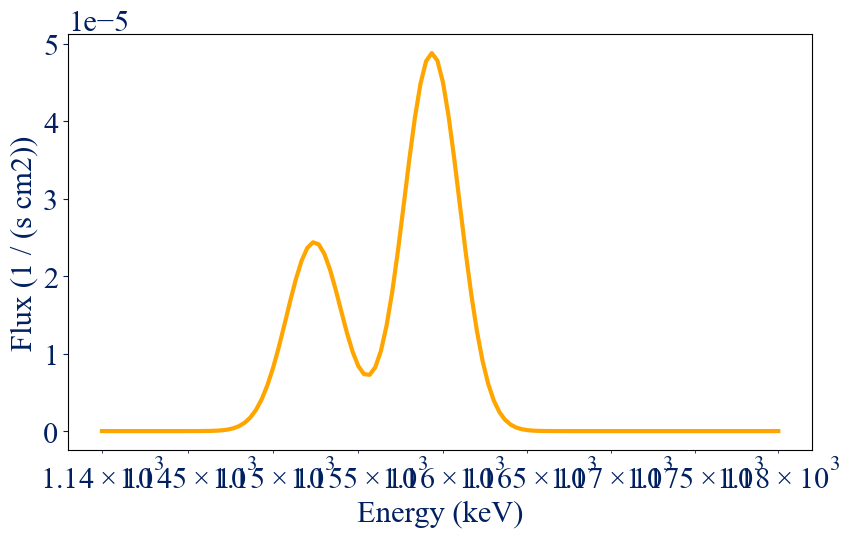

In [380]:
def spectrum_reset(spec):
    if name == 'CasAsymmetric':
        F = 3e-4 / u.cm / u.cm / u.s
        mu = 1157 * u.keV
        sigma = 3.85/2.355 * u.keV

        spec.F.value = F.value
        spec.F.min_value = F.value / 1e3
        spec.F.max_value = F.value * 1e3
        spec.F.unit = F.unit
        spec.mu.value = mu.value 
        spec.mu.min_value = mu.value - 10
        spec.mu.max_value = mu.value + 10
        spec.mu.unit = mu.unit
        spec.sigma.value = sigma.value
        spec.sigma.min_value = sigma.value - 5
        spec.sigma.max_value = sigma.value + 5
        spec.sigma.unit = sigma.unit

    else:
        # Input .source values
        F1 = 1e-4 / u.cm / u.cm / u.s
        mu1 = {'CasAfullyresolved': 1149.35, 
               'CasApartiallyresolved': 1152.41, 
               'CasAunresolved': 1153.17}
        mu1 = mu1[name] * u.keV
        sigma1 = 3.85 * u.keV / 2.355
 
        F2 = 2 * F1
        mu2 = {'CasAfullyresolved': 1160.89, 
               'CasApartiallyresolved': 1159.34, 
               'CasAunresolved': 1158.95}
        mu2 = mu2[name] * u.keV
        sigma2 = sigma1
 
        # Define the first Gaussian
        spec.F_1.value = F1.value
        spec.F_1.min_value = F1.value / 1e3
        spec.F_1.max_value = F1.value #* 1e3
        spec.F_1.unit = F1.unit
        spec.mu_1.value = mu1.value
        spec.mu_1.min_value = mu1.value - 10
        spec.mu_1.max_value = mu1.value + 10
        spec.mu_1.unit = mu1.unit
        spec.sigma_1.value = sigma1.value
        spec.sigma_1.min_value = sigma1.value - 5
        spec.sigma_1.max_value = sigma1.value + 5
        spec.sigma_1.unit = sigma1.unit
 
        # Define the second Gaussian
        spec.F_2.value = F2.value
        spec.F_2.min_value = F2.value / 1e3
        spec.F_2.max_value = F2.value * 1e3
        spec.F_2.unit = F2.unit
        spec.mu_2.value = mu2.value
        spec.mu_2.min_value = mu2.value - 10
        spec.mu_2.max_value = mu2.value + 10
        spec.mu_2.unit = mu2.unit
        spec.sigma_2.value = sigma2.value
        spec.sigma_2.min_value = sigma2.value - 5
        spec.sigma_2.max_value = sigma2.value + 5
        spec.sigma_2.unit = sigma2.unit

    return spec

if name == 'CasAsymmetric':
    spectrum = Gaussian()
    spectrum = spectrum_reset(spectrum)
    spectrum_unit = spectrum.F.unit / spectrum.sigma.unit 

    spectrum.F.free = True
    spectrum.mu.free = True
    spectrum.sigma.free = True

else:
    # Create the compound model
    gaussian1 = Gaussian()
    gaussian2 = Gaussian()
    spectrum = gaussian1 + gaussian2
    spectrum = spectrum_reset(spectrum)
    spectrum_unit = spectrum.F_1.unit / spectrum.sigma_1.unit 
    
    spectrum.F_1.free = True
    spectrum.mu_1.free = False
    spectrum.sigma_1.free = False
    spectrum.F_2.free = True
    spectrum.mu_2.free = False
    spectrum.sigma_2.free = False
    

# Generate some data for plotting
xdata = np.linspace(1140, 1180, 121) * u.keV
ydata = spectrum(xdata.value) * spectrum_unit

# Plot the compound model
plt.plot(xdata.value, ydata)
plt.xlabel(f'Energy ({xdata.unit})')
plt.ylabel(f'Flux ({spectrum_unit * u.keV})')
# plt.ylim([0, 1e-5])
plt.xscale('log')
plt.show()

In [381]:
exposure_time = 92.34 * u.d * (len(energy_samples) / len(data['Energies'])) * 4/5 #* 5/6 #* 1/4      # 3 month total, SAA cut, 25% FOV (required fudge factor based on empirical testing through above rate plots was ~0.215 = 5/24)
print(len(np.where((data['Energies'] > 1154) & (data['Energies'] < 1160))[0]), len(data['Energies']))
Aeff = dr.get_effective_area

7778 42216


In [385]:
cosi = COSILikeNew('cosi',                                                     # COSI 3ML plugin
                 dr2 = dr2,                                                     # detector response
                 exposure_time = exposure_time,
                 energy_samples = energy_samples,
                 phi_samples = phi_samples,
                 psi_samples = Psi_sc_onaxis,
                 chi_samples = Chi_sc_onaxis, 
                 spectrum_unit = spectrum_unit,
                 Eiedges = np.array([1150, 1164]) * u.keV,
                 nuisance_param = {}                                            # background parameter)       
)   

target_coord = SkyCoord.from_name('Crab').galactic
source = PointSource('source', 
                     l = target_coord.l.value,
                     b = target_coord.b.value,
                     spectral_shape = spectrum)
model = Model(source)
cosi.set_model(model)

In [390]:
plugins = DataList(cosi) # If we had multiple instruments, we would do e.g. DataList(cosi, lat, hawc, ...)

like = JointLikelihood(model, plugins, verbose = False)

like.fit()

19:02:10 INFO      set the minimizer to minuit                                             ]8;id=545129;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=716693;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py#1045\1045]8;;\

0it [00:00, ?it/s]
WARNING UserWarning: len(target) != len(dr.axes)

1000it [00:00, 1220.87it/s]
1000it [00:00, 1270.32it/s]
1000it [00:00, 1293.45it/s]
1000it [00:00, 1321.79it/s]
1000it [00:00, 1307.43it/s]
1000it [00:00, 1314.09it/s]
1000it [00:00, 1301.18it/s]
1000it [00:00, 1299.64it/s]
1000it [00:00, 1334.79it/s]
1000it [00:00, 1325.17it/s]
1000it [00:00, 1310.59it/s]
1000it [00:00, 1284.40it/s]
1000it [00:00, 1286.23it/s]
1000it [00:00, 1181.41it/s]
1000it [00:00, 1157.33it/s]
1000it [00:00, 1174.51it/s]
1000it [00:00, 1092.96it/s]
1000it [00:00, 1086.06it/s]
1000it [00:00, 1097.92it/s]
1000it [00:00, 1239.56it/s]
1000it [00:00, 1269.21it/s]
1000it [00:00, 1249.72it/s]
1000it [00:00, 1043.82it/s]
1000it [00:00, 1285.97it/s]
1000it [00:00, 1273.38it/s]
1000it [00:00, 1251.67it/s]
1000it [00:00, 1266.43it/s]
1000it [00:00, 1270.38it/s]
1000it [00:00, 1276.11it/s]
1000it [00:00, 1280.11it/s]
1000it [00:00, 1272.11it/s]
1000it [00:00, 1200.97it/s]
1000it [00:00, 1125.11it/s]
1000it 

19:02:50 WARNING   76.55999999999999 percent of samples have been thrown away because they ]8;id=520775;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/analysis_results.py\analysis_results.py]8;;\:]8;id=795179;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/analysis_results.py#1740\1740]8;;\
                  failed the constraints on the parameters. This results might not be                              
                  suitable for error propagation. Enlarge the boundaries until you loose                           
                  less than 1 percent of the samples.                                                              

19:02:50 WARNING   The current value of the parameter F_1 (1.0) was above the new maximum 0.0001.  ]8;id=616970;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=638486;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu_1 (0.0) was below the new minimum         ]8;id=930201;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=94957;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\
                  1142.41.                                                                                         

...

Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,12170.986471677472
total,12170.986471677472


Values of statistical measures:

,statistical measures
AIC,24345.98497946327
BIC,24355.788453912908


(                                       value  negative_error  positive_error  \
 source.spectrum.main.composite.F_1  0.000093       -0.000077       -0.000010   
 source.spectrum.main.composite.F_2  0.000200        0.000009        0.000072   
 
                                        error         unit  
 source.spectrum.main.composite.F_1  0.000033  1 / (s cm2)  
 source.spectrum.main.composite.F_2  0.000040  1 / (s cm2)  ,
          -log(likelihood)
 cosi   12170.986471677472
 total  12170.986471677472)

In [391]:
results = like.results

print(results.display())

parameters = {par.name:results.get_variates(par.path)
              for par in results.optimized_model["source"].parameters.values()
              if par.free}

results_err = results.propagate(results.optimized_model["source"].spectrum.main.shape.evaluate_at, **parameters)

print(results.optimized_model["source"])

Best fit values:

,result,unit
parameter,,
source.spectrum.main.composite.F_1,(0.9 +/- 1.7) x 10^-4,1 / (s cm2)
source.spectrum.main.composite.F_2,(2.0 +/- 1.5) x 10^-4,1 / (s cm2)


Correlation matrix:

1.00,-1.00
-1.00,1.00


Values of -log(likelihood) at the minimum:

...

         WARNING   The current value of the parameter F_1 (1.0) was above the new maximum 0.0001.  ]8;id=771011;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=175148;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu_1 (0.0) was below the new minimum         ]8;id=707447;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=208168;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\
                  1142.41.                                                                                         

         WARNING   The current value of the parameter F_2 (1.0) was above the new maximum 0.2.     ]8;id=374393;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=440148;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu_2 (0.0) was below the new minimum         ]8;id=848783;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=450025;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\
                  1149.34.                                                                                         

  * source (point source):
    * position:
      * l:
        * value: 184.5546550034881
        * desc: Galactic longitude
        * min_value: 0.0
        * max_value: 360.0
        * unit: deg
        * is_normalization: false
      * b:
        * value: -5.783339352016454
        * desc: Galactic latitude
        * min_value: -90.0
        * max_value: 90.0
        * unit: deg
        * is_normalization: false
      * equinox: J2000
    * spectrum:
      * main:
        * composite:
          * F_1:
            * value: 9.34555760467413e-05
            * desc: Integral between -inf and +inf. Fix this to 1 to obtain a Normal distribution
            * min_value: 1.0000000000000001e-07
            * max_value: 0.0001
            * unit: s-1 cm-2
            * is_normalization: false
          * mu_1:
            * value: 1152.41
            * desc: Central value
            * min_value: 1142.41
            * max_value: 1162.41
            * unit: keV
            * is_normalization: f

In [392]:
energy = np.linspace(1150*u.keV,1164*u.keV).to_value(u.keV)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux = results_err(e)
    flux_median[i] = flux.median
    flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)
    spectrum_inj = spectrum_reset(spec=spectrum)
    flux_inj[i] = spectrum_inj.evaluate_at(e)

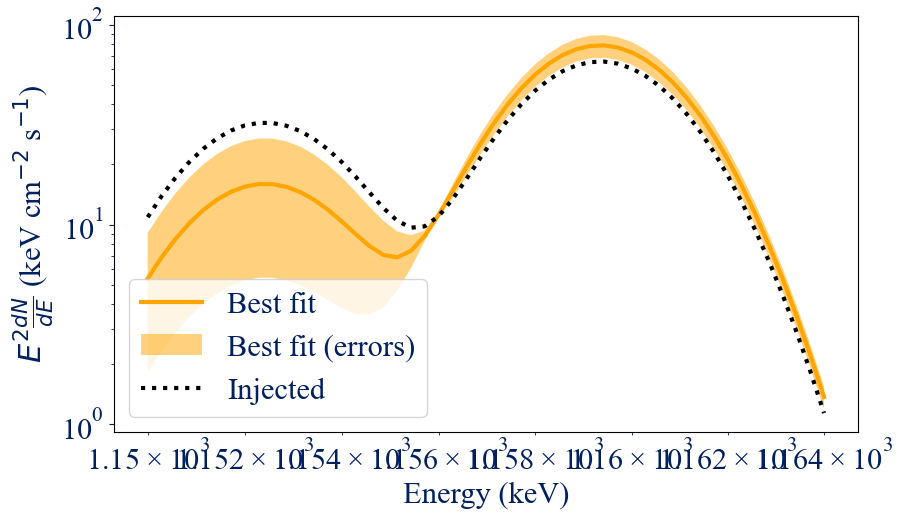

In [393]:
fig,ax = plt.subplots()

ax.plot(energy, energy*energy*flux_median, label = "Best fit")
ax.fill_between(energy, energy*energy*flux_lo, energy*energy*flux_hi, alpha = .5, label = "Best fit (errors)")
ax.plot(energy, energy*energy*flux_inj, color = 'black', ls = ":", label = "Injected")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel(r"$E^2 \frac{dN}{dE}$ (keV cm$^{-2}$ s$^{-1}$)")

ax.legend()

In [344]:
cosi._compute_predicted_c()

<Quantity 516.51700706>

In [345]:
aj = cosi._compute_predicted_a()
np.sum(np.log(aj+1e-12))

0it [00:00, ?it/s]
WARNING UserWarning: len(target) != len(dr.axes)

1000it [00:00, 1231.77it/s]


<Quantity -5746.1402986>

In [249]:
cosi_spectrum = cosi._likelihood_model.source.spectrum.main.shape
cosi_spectrum = spectrum_reset(spec=cosi_spectrum)

logL_values = []
prefactor_values = np.geomspace(F/10, F*100, 16)
for F_value in prefactor_values:
    cosi._likelihood_model.source.spectrum.main.shape.F.value = F_value
    logL_values.append(cosi.get_log_like())

0it [00:00, ?it/s]
WARNING UserWarning: len(target) != len(dr.axes)

1000it [00:00, 1271.97it/s]
1000it [00:00, 1316.17it/s]
1000it [00:00, 1245.52it/s]
1000it [00:00, 1272.35it/s]
1000it [00:00, 1301.42it/s]
1000it [00:00, 1297.80it/s]
1000it [00:00, 1296.06it/s]
1000it [00:00, 1293.24it/s]
1000it [00:00, 1298.23it/s]
1000it [00:00, 1303.09it/s]
1000it [00:00, 1265.79it/s]
1000it [00:00, 1290.96it/s]
1000it [00:00, 1288.98it/s]
1000it [00:00, 1140.54it/s]
1000it [00:00, 1290.35it/s]
1000it [00:00, 1285.17it/s]


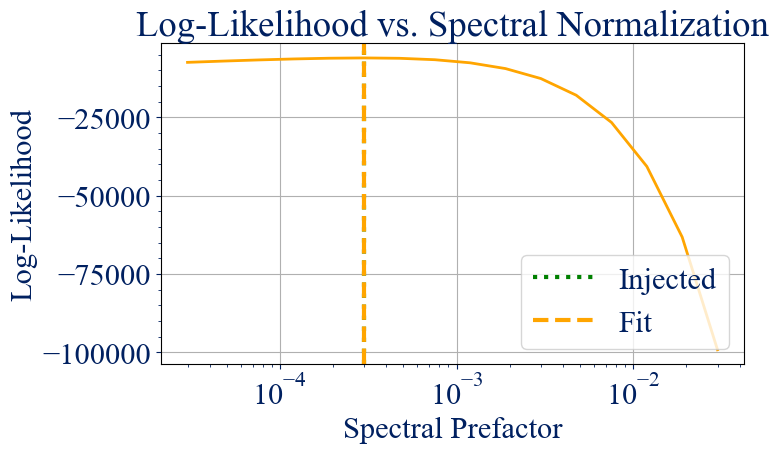

In [252]:
plt.figure(figsize=(8, 5))
plt.plot(prefactor_values, logL_values, lw=2)
plt.xscale('log')
plt.xlabel("Spectral Prefactor")
plt.ylabel("Log-Likelihood")
plt.title("Log-Likelihood vs. Spectral Normalization")
plt.axvline(F.value, ls=':', c='g', label='Injected')
plt.axvline(prefactor_values[np.argmax(logL_values)].value, ls='--', label='Fit')
# plt.axhline(np.max(logL_values), ls='--', label='Fit')
plt.legend()
# plt.ylim(bottom=0)
plt.minorticks_on()
plt.grid(True)
plt.tight_layout()
plt.show()

In [253]:
cosi_spectrum = cosi._likelihood_model.source.spectrum.main.shape
cosi_spectrum = spectrum_reset(spec=cosi_spectrum)

logL_values = []
values = np.linspace(1150, 1164, 15)
for mu_value in values:
    cosi_spectrum.mu.value = mu_value
# for exp_time in np.linspace(17.44, 18.04, 4) * u.d:
#     cosi._exposure_time = exp_time
#     values = np.linspace(1, 2.4, 15)
#     for sigma_value in values:
#         cosi_spectrum.sigma.value = sigma_value
    logL_values.append(cosi.get_log_like())

0it [00:00, ?it/s]
WARNING UserWarning: len(target) != len(dr.axes)

1000it [00:00, 1251.31it/s]
1000it [00:00, 1285.92it/s]
1000it [00:00, 1214.45it/s]
1000it [00:00, 1241.18it/s]
1000it [00:00, 1234.75it/s]
1000it [00:00, 1264.66it/s]
1000it [00:00, 1312.40it/s]
1000it [00:00, 1301.57it/s]
1000it [00:00, 1311.44it/s]
1000it [00:00, 1297.12it/s]
1000it [00:00, 1296.01it/s]
1000it [00:00, 1311.93it/s]
1000it [00:00, 1278.08it/s]
1000it [00:00, 1306.85it/s]
1000it [00:00, 1307.29it/s]


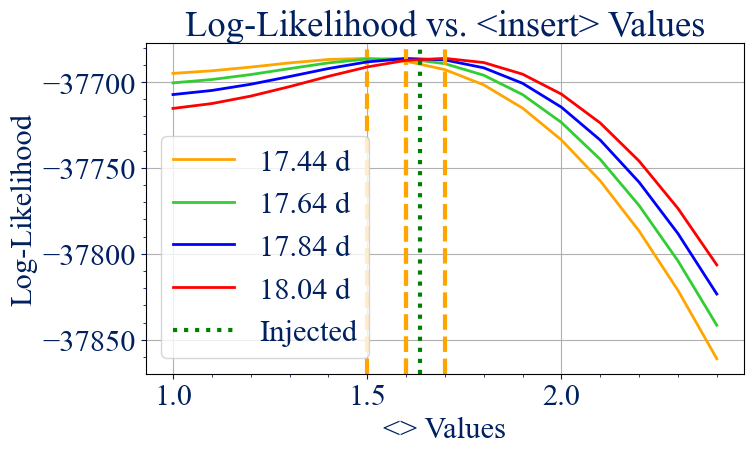

In [ ]:
plt.figure(figsize=(8, 5))
# plt.plot(values, logL_values, lw=2)
for logL, exp_time in zip(np.reshape(logL_values, (4,15)), np.linspace(17.44, 18.04, 4)*u.d):
    plt.plot(values, logL, lw=2, label=f'{exp_time}')
    plt.axvline(values[np.nanargmax(logL)], ls='--')
# plt.xscale('log')
plt.xlabel("<> Values")
plt.ylabel("Log-Likelihood")
plt.title("Log-Likelihood vs. <insert> Values")
# plt.axvline(mu.value, ls=':', c='g', label='Injected')
plt.axvline(sigma.value, ls=':', c='g', label='Injected')
# plt.axvline(values[np.nanargmax(logL_values)], ls='--', label='Fit')
# plt.axhline(np.max(logL_values), ls='--', label='Fit')
# plt.ylim(bottom=-40000)
plt.minorticks_on()
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

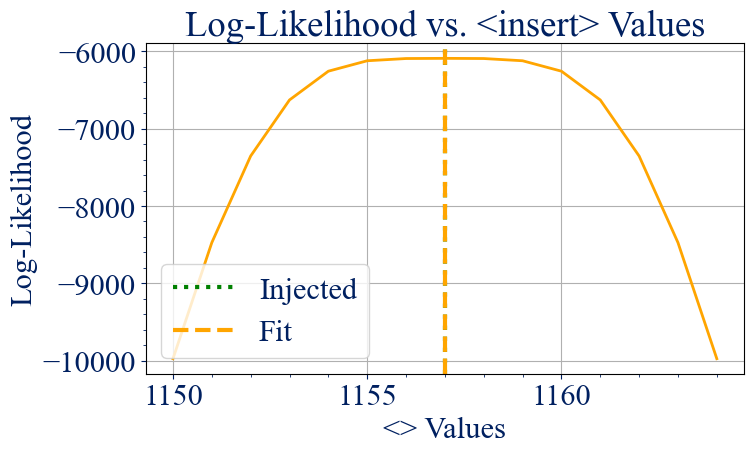

In [254]:
plt.figure(figsize=(8, 5))
plt.plot(values, logL_values, lw=2)
# plt.xscale('log')
plt.xlabel("<> Values")
plt.ylabel("Log-Likelihood")
plt.title("Log-Likelihood vs. <insert> Values")
plt.axvline(mu.value, ls=':', c='g', label='Injected')
plt.axvline(values[np.nanargmax(logL_values)], ls='--', label='Fit')
# plt.axhline(np.max(logL_values), ls='--', label='Fit')
# plt.ylim(bottom=-40000)
plt.minorticks_on()
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

In [46]:
Phi0 = 45 * u.deg
Psi_gal0 = 2.388 * u.deg     # b
Chi_gal0 = 337.5 * u.deg       # l
target = {'Phi': Phi0, 'Psi_sc': Psi_gal0, 'Chi_sc': Chi_gal0}

get_interp_response(dr2, target)


WARNING UserWarning: len(target) != len(dr.axes)



<Quantity 1.81444463e-05 cm2>

In [28]:
def _compute_predicted_a():
    aj = []
    Eiedges = np.array([1154, 1160])
    integrated_spectrum = integrate.quad(spectrum, Eiedges[0], Eiedges[-1])[0] * spectrum_unit * u.keV
    for energy, phi, psi, chi in zip(energy_samples, phi_samples, Psi_sc_onaxis * u.deg, Chi_sc_onaxis * u.deg):
        target = {'Phi': phi, 'Psi_sc': psi, 'Chi_sc': chi}
        print(energy, target, get_interp_response(dr2, target))
        aj.append(get_interp_response(dr2, target) * integrated_spectrum * exposure_time.to('s'))
    
    aj = Quantity(aj)
    return aj

def _compute_predicted_c(self):
    # mod_rsp = lambda y, x: get_interp_response(dr2, {'Phi': x, 'PsiChi': y})
    delta_Em = self._delta_Em / u.keV      # Assuming R is normalized over units as listed for each axis. XXX: How exactly is the response file normalized? I can't multiple delta_Em and then not multiply the widths of each Phi and PsiChi bin. 
    Eiedges = self._Eiedges / u.keV
    spectrum = self._likelihood_model.source.spectrum.main.shape
    c = (np.sum(dr2.contents)) * (integrate.quad(spectrum, Eiedges[0], Eiedges[-1])[0] *       # As D and P normalize to 1, np.sum(R) is determined by Aeff.                                                                                                                                                     
        self._spectrum_unit * u.keV) * self._exposure_time.to('s')                  # Interpolated response won't improve anything as we are still going to numerically integrate (i.e., sum over rectangular blocks of area)
    
    return c

In [29]:
target = {'Phi': 2.2923 * u.rad, 'Psi_sc': -12.9791 * u.deg, 'Chi_sc': -138.916 * u.deg}
get_interp_response(dr2, target)


WARNING UserWarning: len(target) != len(dr.axes)



<Quantity 4.78309265e-05 cm2>

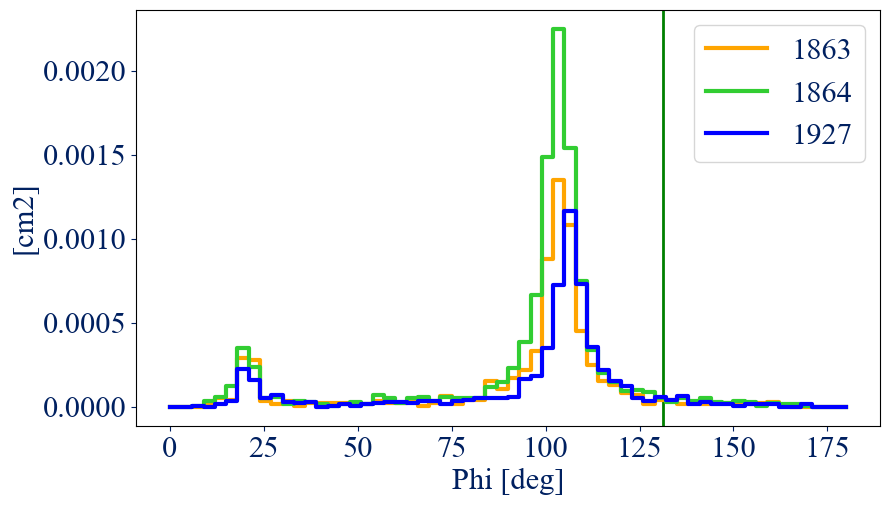

In [ ]:
ax, _ = dr2.slice[:, 1863].project('Phi').plot(label='1863')
dr2.slice[:, 1864].project('Phi').plot(ax=ax, label='1864')
dr2.slice[:, 1927].project('Phi').plot(ax=ax, label='1927')
plt.axvline(target['Phi'].to(u.deg).value, lw=2, c='g')
plt.legend()